In [1]:
import os
import numpy as np
import polars as pl
import tensorflow as tf
import sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.postprocessing.postprocessing import PostProcessor
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [3]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (273.4MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06881000"
	"06784000"
	"06803500"
	"06895000"
	"06869950"
	…
	"06700000"
	"06793000"
	"06093200"
	"06799100"
	"06188000"
]
(4818417, 31)
X_test shape: (338699, 72, 28)
y_test shape: (338699,)


In [4]:
_tmp = LSTMModel()
asymmetric_mse = _tmp._loss()

model = LSTMModel.load_model(
    "lstm_model.keras",
    custom_objects={"asymmetric_mse": asymmetric_mse}
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 32)         │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,293 (141.77 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,196 (94.52 KB)

In [5]:

pp = PostProcessor(
    model=model,
    X_test=X_test,
    y_test=y_test,
    site_ids=test_site_ids,
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES,
)

Excluding from plots: streamflow_cfs_mean, streamflow_cfs_min
Computing SHAP for site 06036650 (100 samples)...

Site 06036650 — Top 5 features:
  Rank   Feature                              Mean |SHAP|
  -------------------------------------------------------
  1      streamflow_cfs_max                       0.00450
  2      temperature_c                            0.00034
  3      gage_height_ft_mean                      0.00034
  4      potential_evaporation_mm                 0.00032
  5      specific_humidity_kgkg                   0.00032

Computing SHAP for site 06061500 (100 samples)...

Site 06061500 — Top 5 features:
  Rank   Feature                              Mean |SHAP|
  -------------------------------------------------------
  1      streamflow_cfs_max                       0.00205
  2      DRAIN_SQKM                               0.00041
  3      latitude                                 0.00025
  4      longitude                                0.00024
  5      snw_pc_s

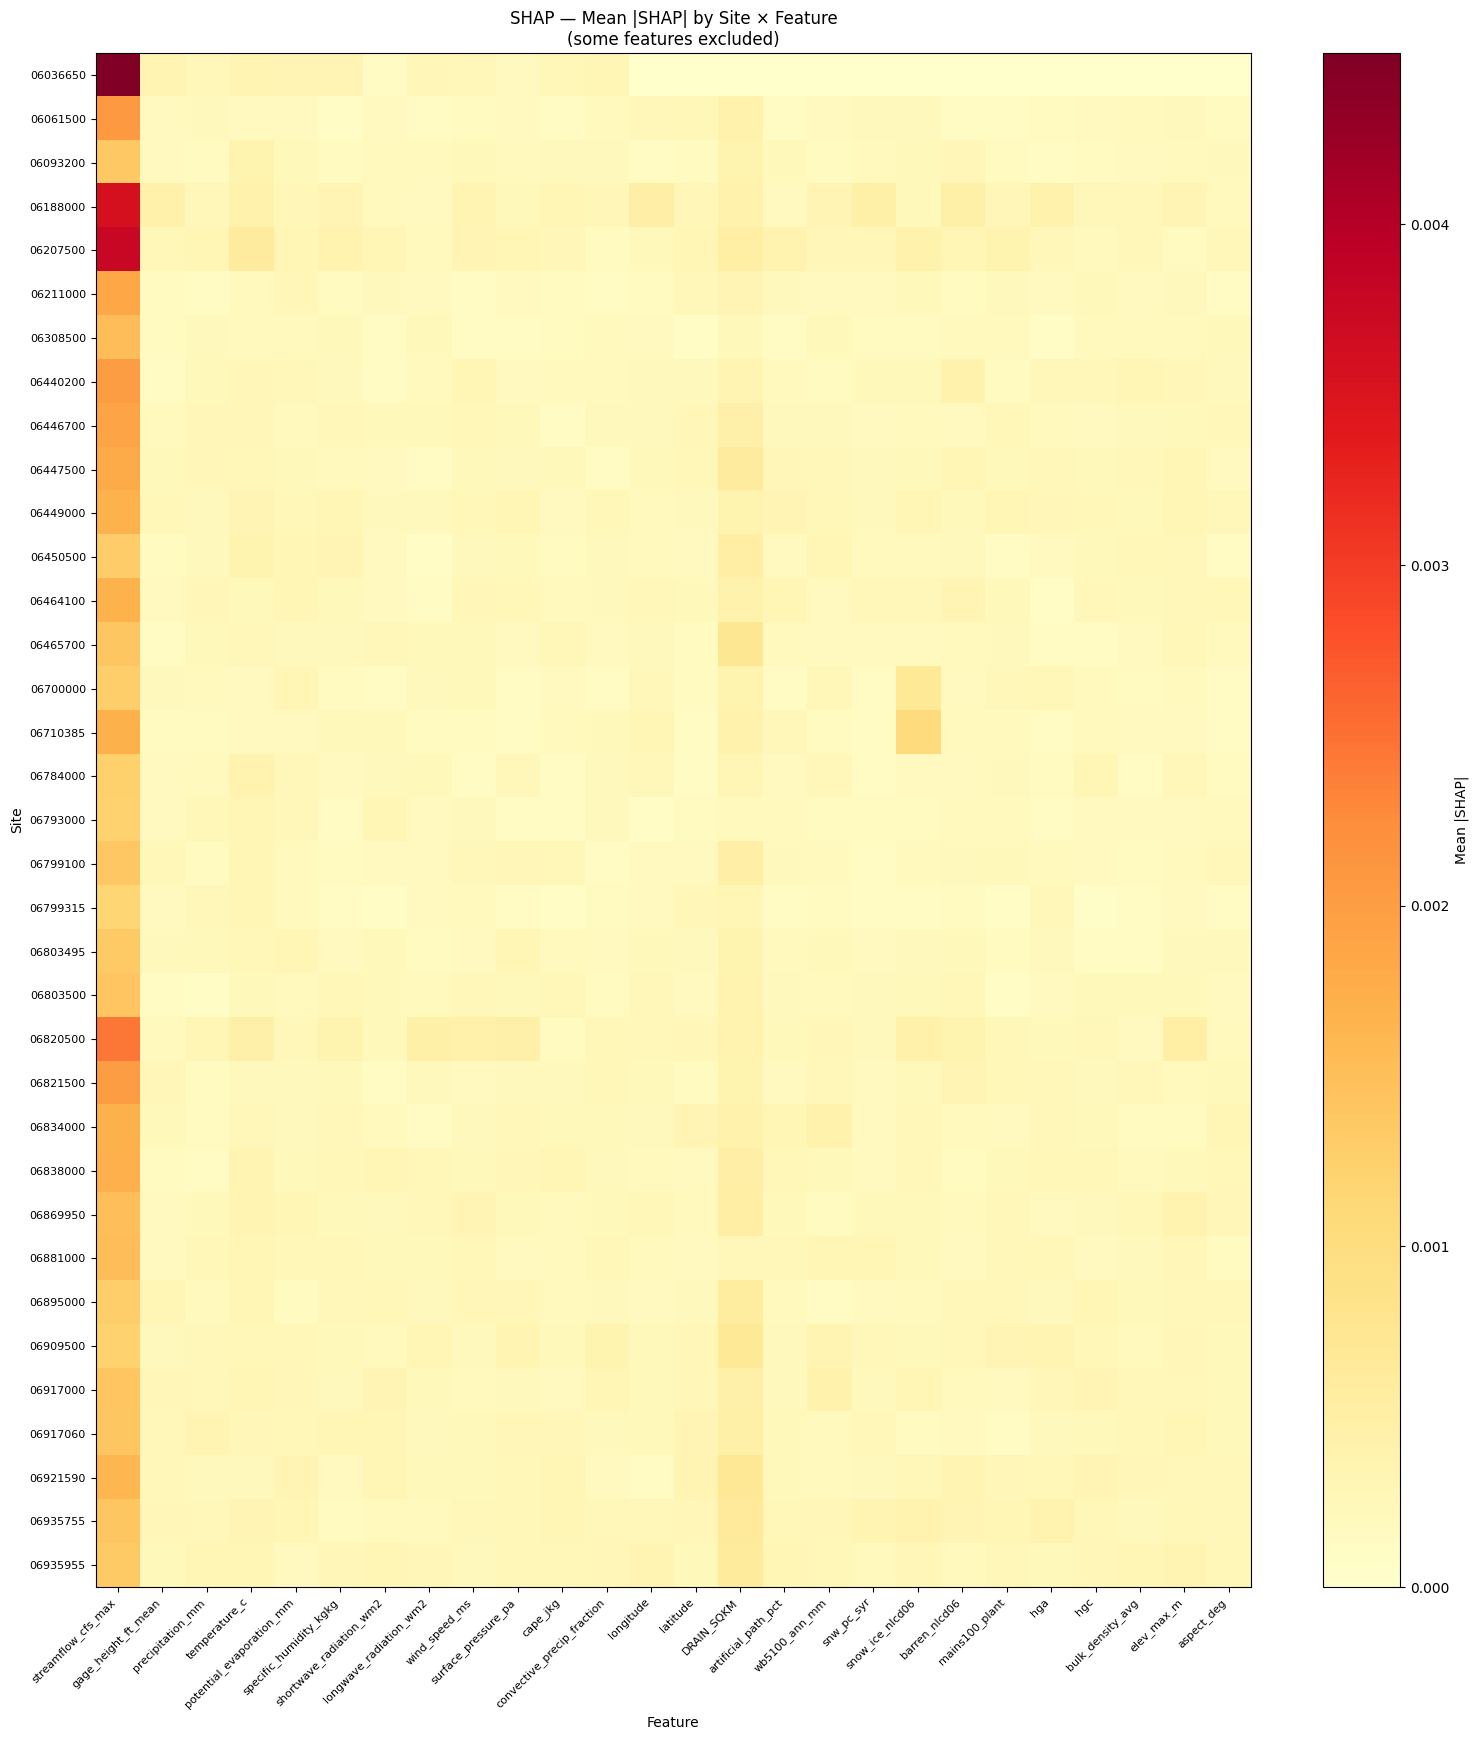

In [6]:
pp.compute_shap_per_site(nsamples=300, max_explain_samples=100, exclude_features=["streamflow_cfs_mean", "streamflow_cfs_min"])